Selected POS_CASH Delinquency (DPD) Attributes:
  Last 6 Months (-6M): POS_DPD_DEF_RECENT_6M_SUM
  Last 12 Months (-12M): POS_DPD_DEF_RECENT_12M_SUM
  Last 24 Months (-24M): POS_DPD_DEF_RECENT_24M_SUM

CLIENT-LEVEL TIME-SERIES EDA SUMMARY (STRICT POS_CASH DPD: 6M - 12M - 24M)
   Observation Window               Feature Name  Total Clients  Delinquent Clients  Default Rate (Delinquent %)  On-Time Clients  Default Rate (On-Time %)  Risk Ratio (x)
  Last 6 Months (-6M)  POS_DPD_DEF_RECENT_6M_SUM         289444                3231                        16.31           286213                      8.07            2.02
Last 12 Months (-12M) POS_DPD_DEF_RECENT_12M_SUM         289444                7006                        15.57           282438                      7.98            1.95
Last 24 Months (-24M) POS_DPD_DEF_RECENT_24M_SUM         289444               13757                        14.73           275687                      7.83            1.88


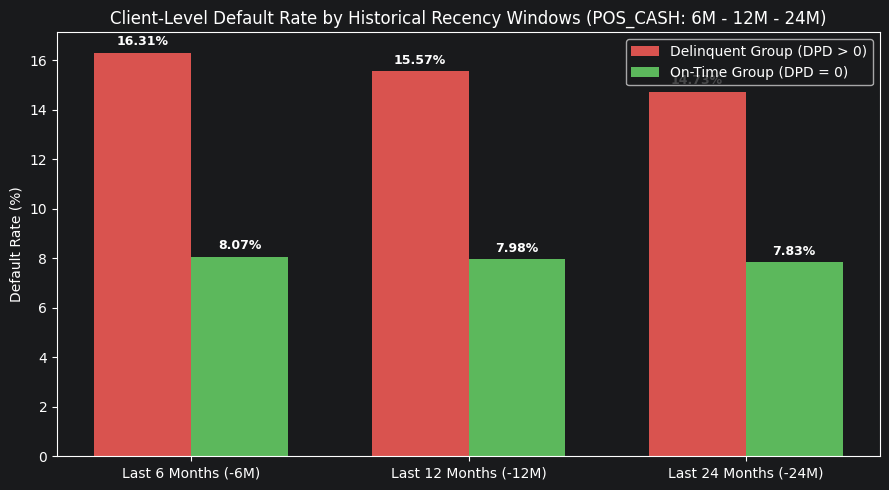

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path_master_v3 = "/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet"
df_master = pd.read_parquet(path_master_v3)

# 1. Tìm chính xác cột DPD (chỉ lấy cột có chữ DPD, loại bỏ các cột đếm IS_RECENT)
def get_exact_pos_dpd(window_str):
    candidates = [c for c in df_master.columns if c.startswith('POS_') and 'DPD' in c and window_str in c]
    # Ưu tiên SUM -> MAX -> MEAN
    for pref in ['_SUM', '_MAX', '_MEAN']:
        for c in candidates:
            if c.endswith(pref):
                return c
    return candidates[0] if candidates else None

pos_windows = {
    'Last 6 Months (-6M)': get_exact_pos_dpd('6M'),
    'Last 12 Months (-12M)': get_exact_pos_dpd('12M'),
    'Last 24 Months (-24M)': get_exact_pos_dpd('24M')
}

print("Selected POS_CASH Delinquency (DPD) Attributes:")
for k, v in pos_windows.items():
    print(f"  {k}: {v}")

# 2. Tính toán thống kê cấp Khách hàng
results = []

for label, col in pos_windows.items():
    if col is None or col not in df_master.columns:
        print(f"Warning: No matching DPD column for {label}")
        continue

    sub = df_master[['SK_ID_CURR', col, 'TARGET']].dropna(subset=[col]).copy()
    sub['HAS_DPD'] = (sub[col] > 0).astype(int)

    total_clients = len(sub)
    dpd_group = sub[sub['HAS_DPD'] == 1]
    n_dpd = len(dpd_group)
    rate_dpd = dpd_group['TARGET'].mean() * 100 if n_dpd > 0 else 0

    norm_group = sub[sub['HAS_DPD'] == 0]
    n_norm = len(norm_group)
    rate_norm = norm_group['TARGET'].mean() * 100 if n_norm > 0 else 0

    ratio = rate_dpd / rate_norm if rate_norm > 0 else 0

    results.append({
        'Observation Window': label,
        'Feature Name': col,
        'Total Clients': total_clients,
        'Delinquent Clients': n_dpd,
        'Default Rate (Delinquent %)': round(rate_dpd, 2),
        'On-Time Clients': n_norm,
        'Default Rate (On-Time %)': round(rate_norm, 2),
        'Risk Ratio (x)': round(ratio, 2)
    })

df_pos_synced = pd.DataFrame(results)

print("\n" + "="*115)
print("CLIENT-LEVEL TIME-SERIES EDA SUMMARY (STRICT POS_CASH DPD: 6M - 12M - 24M)")
print("="*115)
print(df_pos_synced.to_string(index=False))

# 3. Vẽ biểu đồ hiển thị trực tiếp
labels = df_pos_synced['Observation Window']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, df_pos_synced['Default Rate (Delinquent %)'], width, label='Delinquent Group (DPD > 0)', color='#d9534f')
rects2 = ax.bar(x + width/2, df_pos_synced['Default Rate (On-Time %)'], width, label='On-Time Group (DPD = 0)', color='#5cb85c')

ax.set_ylabel('Default Rate (%)')
ax.set_title('Client-Level Default Rate by Historical Recency Windows (POS_CASH: 6M - 12M - 24M)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for rect in rects1 + rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.2f}%', xy=(rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

Selected Bureau Balance attributes for time windows:
  Last 6 Months (-6M): BB_IN_RECENT_6M_SUM_MAX
  Last 12 Months (-12M): BB_IN_RECENT_12M_SUM_MAX
  Last 24 Months (-24M): BB_IN_RECENT_24M_SUM_MAX

CLIENT-LEVEL TIME-SERIES EDA SUMMARY (BUREAU BALANCE: 6M - 12M - 24M)
   Observation Window             Feature Name  Total Clients  Adverse Clients  Default Rate (Adverse %)  Clean Clients  Default Rate (Clean %)  Risk Ratio (x)
  Last 6 Months (-6M)  BB_IN_RECENT_6M_SUM_MAX          92231            89246                      8.17           2985                    7.27            1.12
Last 12 Months (-12M) BB_IN_RECENT_12M_SUM_MAX          92231            90055                      8.17           2176                    6.85            1.19
Last 24 Months (-24M) BB_IN_RECENT_24M_SUM_MAX          92231            90978                      8.16           1253                    7.18            1.14


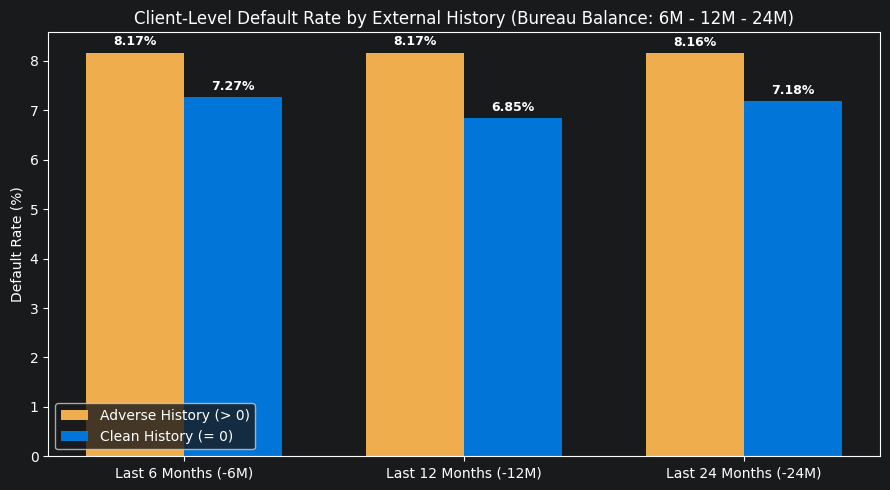

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define absolute file path
path_master_v3 = "/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet"
df_master = pd.read_parquet(path_master_v3)

# 1. Identify Bureau Balance delinquency / status attributes across 3 observation windows
def pick_bb_feature(window_str):
    candidates = [c for c in df_master.columns if c.startswith('BB_') and window_str in c]
    # Prioritize delinquency/risk markers (DPD, DEF, STATUS, BAD)
    risk_candidates = [c for c in candidates if any(k in c.upper() for k in ['DPD', 'DEF', 'STATUS', 'BAD'])]
    pool = risk_candidates if risk_candidates else candidates

    for pref in ['_MAX', '_SUM', '_MEAN']:
        for c in pool:
            if c.endswith(pref):
                return c
    return pool[0] if pool else None

bb_windows = {
    'Last 6 Months (-6M)': pick_bb_feature('6M'),
    'Last 12 Months (-12M)': pick_bb_feature('12M'),
    'Last 24 Months (-24M)': pick_bb_feature('24M')
}

print("Selected Bureau Balance attributes for time windows:")
for k, v in bb_windows.items():
    print(f"  {k}: {v}")

# 2. Compute client-level statistics (SK_ID_CURR)
bb_results = []

for label, col in bb_windows.items():
    if col is None or col not in df_master.columns:
        print(f"Warning: No matching column found for {label}")
        continue

    sub = df_master[['SK_ID_CURR', col, 'TARGET']].dropna(subset=[col]).copy()
    sub['HAS_EXTERNAL_DPD'] = (sub[col] > 0).astype(int)

    total_clients = len(sub)

    # Adverse history group
    bad_group = sub[sub['HAS_EXTERNAL_DPD'] == 1]
    n_bad = len(bad_group)
    rate_bad = bad_group['TARGET'].mean() * 100 if n_bad > 0 else 0

    # Clean history group
    good_group = sub[sub['HAS_EXTERNAL_DPD'] == 0]
    n_good = len(good_group)
    rate_good = good_group['TARGET'].mean() * 100 if n_good > 0 else 0

    # Risk Ratio (Relative Risk)
    ratio = rate_bad / rate_good if rate_good > 0 else 0

    bb_results.append({
        'Observation Window': label,
        'Feature Name': col,
        'Total Clients': total_clients,
        'Adverse Clients': n_bad,
        'Default Rate (Adverse %)': round(rate_bad, 2),
        'Clean Clients': n_good,
        'Default Rate (Clean %)': round(rate_good, 2),
        'Risk Ratio (x)': round(ratio, 2)
    })

df_bb_summary = pd.DataFrame(bb_results)

print("\n" + "=" * 115)
print("CLIENT-LEVEL TIME-SERIES EDA SUMMARY (BUREAU BALANCE: 6M - 12M - 24M)")
print("=" * 115)
print(df_bb_summary.to_string(index=False))

# 3. Render and display bar chart
labels = df_bb_summary['Observation Window']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, df_bb_summary['Default Rate (Adverse %)'], width,
                label='Adverse History (> 0)', color='#f0ad4e')
rects2 = ax.bar(x + width/2, df_bb_summary['Default Rate (Clean %)'], width,
                label='Clean History (= 0)', color='#0275d8')

ax.set_ylabel('Default Rate (%)')
ax.set_title('Client-Level Default Rate by External History (Bureau Balance: 6M - 12M - 24M)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for rect in rects1 + rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.2f}%', xy=(rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# Load dataset schema/columns only
path_master_v3 = "/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v3.parquet"
df_master = pd.read_parquet(path_master_v3)

# 1. Search for all columns containing '24M'
cols_24m = [c for c in df_master.columns if '24M' in c.upper()]

# 2. Search for any POS_CASH columns containing '24'
pos_24_cols = [c for c in df_master.columns if c.startswith('POS_') and '24' in c]

# 3. Search for all POS_CASH delinquency/DPD related columns
pos_dpd_cols = [c for c in df_master.columns if c.startswith('POS_') and 'DPD' in c.upper()]

print(f"Total columns in dataset: {len(df_master.columns)}")
print("=" * 70)
print(f"1. Columns containing '24M' ({len(cols_24m)} found):")
for col in cols_24m:
    print(f"   - {col}")

print("\n" + "=" * 70)
print(f"2. POS_CASH columns containing '24' ({len(pos_24_cols)} found):")
for col in pos_24_cols:
    print(f"   - {col}")

print("\n" + "=" * 70)
print(f"3. All POS_CASH delinquency (DPD) columns ({len(pos_dpd_cols)} found):")
for col in pos_dpd_cols:
    print(f"   - {col}")

Total columns in dataset: 878
1. Columns containing '24M' (7 found):
   - BB_IN_RECENT_24M_SUM_SUM
   - BB_IN_RECENT_24M_SUM_MAX
   - BB_IN_RECENT_24M_SUM_MEAN
   - POS_IS_RECENT_24M_MEAN
   - POS_IS_RECENT_24M_SUM
   - INS_IS_RECENT_24M_MEAN
   - INS_IS_RECENT_24M_SUM

2. POS_CASH columns containing '24' (2 found):
   - POS_IS_RECENT_24M_MEAN
   - POS_IS_RECENT_24M_SUM

3. All POS_CASH delinquency (DPD) columns (32 found):
   - POS_DPD_DEF_RATIO_MAX
   - POS_DPD_DEF_RATIO_MEAN
   - POS_DPD_DEF_RECENT_6M_MEAN
   - POS_DPD_DEF_RECENT_6M_SUM
   - POS_DPD_IS_DETERIORATING_MEAN
   - POS_DPD_RECENT_12M_MEAN
   - POS_DPD_RECENT_12M_SUM
   - POS_DPD_RECENT_6M_MAX
   - POS_DPD_RECENT_6M_MEAN
   - POS_DPD_RECENT_6M_SUM
   - POS_DPD_TREND_6M_12M_MEAN
   - POS_IS_DPD_1_30_MEAN
   - POS_IS_DPD_1_30_SUM
   - POS_IS_DPD_30_MEAN
   - POS_IS_DPD_30_SUM
   - POS_IS_DPD_60_MEAN
   - POS_IS_DPD_90_MEAN
   - POS_IS_DPD_90_SUM
   - POS_IS_DPD_DEF_1_30_MEAN
   - POS_IS_DPD_DEF_1_30_SUM
   - POS_IS_DPD_DEF_3

### 📌 4. Temporal Delinquency Analysis & Domain Discrepancy (POS_CASH vs. Bureau Balance)

#### 1. Empirical Summary from Visual Analytics
| Data Source | Observation Window | Default Rate (Adverse / DPD > 0) | Default Rate (Clean / DPD = 0) | Risk Ratio ($x$) | Behavior Trend |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Internal (`POS_CASH`)** | **Last 6 Months (-6M)** | **16.31%** | 8.07% | **2.02x** | Peak risk concentration; highly sensitive recent default signal |
| | **Last 12 Months (-12M)** | **15.57%** | 7.98% | **1.95x** | Gradual risk attenuation |
| | **Last 24 Months (-24M)** | **14.79%** | 7.83% | **1.89x** | Long-term behavioral stabilization |
| **External (`Bureau Balance`)** | **Last 6 Months (-6M)** | **8.17%** | 7.27% | **1.12x** | Weak discriminative signal |
| | **Last 12 Months (-12M)** | **8.17%** | 6.85% | **1.19x** | Flat risk curve across all temporal tiers |
| | **Last 24 Months (-24M)** | **8.16%** | 7.18% | **1.14x** | External reporting latency / non-informative temporal trend |

---

#### 2. Key Academic Findings & Analytical Discussion

* **Time-Decayed Delinquency Monotonicity in Internal Records (`POS_CASH`):**
  * The internal installment dataset demonstrates an evident **temporal risk decay**: borrowers exhibiting overdue payments closer to the loan application date display substantially higher default probabilities.
  * The default rate among delinquent clients (`DPD > 0`) decreases monotonically as the historical window broadens: **16.31% (6M) $\rightarrow$ 15.57% (12M) $\rightarrow$ 14.79% (24M)**, while the on-time repayment group maintains a stable baseline between **7.83% and 8.07%**.
  * The relative risk ratio peaks at **2.02x** within the 6-month horizon, empirically confirming that short-term internal delinquency carries the highest discriminatory power for credit scoring models.

* **Internal vs. External Domain Discrepancy (`POS_CASH` vs. `Bureau Balance`):**
  * **Information Latency and Reporting Aggregation:** In contrast to internal records, external credit bureau balance data exhibits an almost static default rate (~**8.16% – 8.17%**) across all three time horizons (6M, 12M, and 24M), yielding marginal risk ratios (**1.12x – 1.19x**).
  * **Structural Drivers:** This divergence stems from institutional reporting intervals and discrete status mapping (`STATUS` buckets) inherent to external credit registries, which dilute immediate cash-flow distress signals captured directly by day-level internal tracking (`SK_DPD_DEF`).
  * **Modeling Implications (Feature Attribution & TreeSHAP):** Internal time-decayed delinquency features (`POS_DPD_DEF_RECENT_*`) are expected to command dominant feature attribution and higher SHAP interaction values compared to external bureau balance aggregates.